# Example: Payoff and Profit of Composite Contracts at Expiration
In this example, we will analyze the payoff and profit of composite contracts built from long and short call and put contracts written on the same underlying asset with the same expiration date.

> __Learning Objectives__
> 
> By the end of this example, you should be able to:
> * __Compute profit diagrams__ for composite options strategies including vertical spreads, straddles, and strangles, by combining the payoff of each leg with the net premium paid or received when the position opens.
> * __Analyze directional strategies__ such as credit spreads, whose maximum profit and maximum loss are both finite and known before the trade is placed, and locate their single breakeven price.
> * __State the bounds of neutral strategies correctly.__ Straddles and strangles have two breakeven prices, and their extremes are asymmetric: unbounded only on the __upside__, and finite on the downside because the underlying price cannot fall below zero.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
To start, load the options data using [the `MyOptionsChainDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyOptionsChainDataSet) and store the data in the `metadata::Dict{String,Any}` and `optionschain::DataFrame` variables.

In [2]:
metadata, optionschain = let
    
    # initialize -
    options_dataset = MyOptionsChainDataSet(ticker="amd");
    metadata = options_dataset.metadata;
    optionschain = options_dataset.data;

    (metadata, optionschain) # return
end;

What's in the metadata dictionary? Let's display the fields __and their values__, since the days to expiration, the snapshot date, and the recorded share price are all quoted later in this notebook.

In [3]:
let
    ks = sort(collect(keys(metadata))); # sort: Dict iteration order is not defined
    DataFrame(field = ks, value = [string(metadata[k]) for k in ks])
end

Row,field,value
,String,String
1,DTE,58
2,atm_IV,0.5903
3,expiration_date,2025-12-19
4,historical_volatility,0.7971
5,is_weekly,false
6,purchase_date,2025-10-22
7,source,barchart.com
8,underlying_share_price_ask,225.91
9,underlying_share_price_bid,225.74


What about the optionschain variable?

In [4]:
 optionschain

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,0.8907,203.1,204.0,204.9,209.72,0,419,2.1122,0.9989,Call
2,30.0,0.8688,198.2,199.05,199.9,206.3,0,163,1.9784,0.9985,Call
3,35.0,0.847,193.2,193.98,194.75,199.75,0,17,0.0,0.0,Call
4,40.0,0.8251,188.3,189.1,189.9,176.24,0,18,1.6654,0.9985,Call
5,45.0,0.8033,183.25,184.13,185.0,174.11,0,318,1.5375,0.9985,Call
6,50.0,0.7814,178.4,179.1,179.8,167.46,0,691,1.2356,0.9996,Call
7,55.0,0.7596,173.35,174.13,174.9,177.43,0,176,1.0885,0.9998,Call
8,60.0,0.7377,168.5,169.3,170.1,162.15,0,332,1.3802,0.9967,Call
9,65.0,0.7158,163.45,164.33,165.2,175.38,0,180,1.2927,0.9967,Call


### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [5]:
Sₒ = metadata["underlying_share_price_mid"] |> x-> parse(Float64,x); # set the initial share price (this has no importance now because we have the options chain data)

___

## Task 1: Directional: Credit Vertical Spreads
[Vertical spreads](https://www.fidelity.com/bin-public/060_www_fidelity_com/documents/learning-center/Deck_Vertical-spreads.pdf), a defined risk directional strategy, involve buying and selling the same type of option with different strike prices and the same expiration date. Vertical spreads can be opened for a credit or a debit and have defined risk on both sides. Both structures below are opened for a __credit__.

### Bullish put credit spread
A put vertical spread is constructed by combining 2 $\times$ put contracts, a short put contract generates income while the long put contract controls downside risk. This trade has a bullish outlook on the underlying asset.

> __Bullish put credit spread:__ 
> 
> Let's build a bullish put credit spread for AMD whose recorded share price is $S_{0} = 225.78$ USD/share. This trade structure is constructed by selling (short) a put with strike $K_{1}$ and buying (long) a put with strike $K_{2}$. 
> 
> * Leg 1: The strike price for the short put leg is given by $K_{1}$ = 220 USD/share with DTE = 58 days
> * Leg 2: The strike price for the long put leg is given by $K_{2}$ = 210 USD/share with DTE = 58 days
> 
> This trade will generate a net credit when opened. Depending on the share price at expiration, the trade can result in a profit or loss. The maximum profit occurs when the share price at expiration is above the higher strike price $K_{1}$. The maximum loss occurs when the share price at expiration is below the lower strike price $K_{2}$.


#### Profit and Breakeven Analysis
Let leg $i$ have strike price $K_{i}$ and premium $P_{i}\geq{0}$ (USD/share). Write $\Pi_{i}^{(p)}(S_{T}) = h_{p}(S_{T};K_{i}) - P_{i}$ for the profit of leg $i$ held __long__, so that direction is carried by the explicit signs below rather than inside the symbol. The share price at expiration is $S_{T}$. Let leg 1 be the short leg $\theta_{1} = -1$ and leg 2 the long leg $\theta_{2} = 1$. Then the profit of the put vertical spread at expiration is given by:

$$\Pi_{\mathcal{C}} = -\Pi_{1}^{(p)}+\Pi_{2}^{(p)}$$

which, after substitution of the profit functions for a put contract, gives:

$$
\Pi_{\mathcal{C}} = \left(K_{2} - S_{T}\right)^{+} - \left(K_{1} - S_{T}\right)^{+} + \left(P_{1} - P_{2}\right)$$

where $h_{p}(S_{T};K) = (K-S_{T})^{+}=\max(K-S_{T},0)$ is the payoff function for a put contract. The first two terms are the net payout of the two legs of the spread, while the last term is the net credit received when the position opens. The maximum possible profit, loss, and breakeven conditions are given by:

* The maximum profit, the net credit $\left(P_{1} - P_{2}\right)$, occurs when $S_{T}\geq{K_{1}}$.
* The __minimum profit__ $K_{2} - K_{1} + \left(P_{1} - P_{2}\right)$ occurs when $S_{T}\leq{K_{2}}$. Note $K_{2}<K_{1}$, so this quantity is negative whenever the credit is smaller than the strike width; it is a signed profit, and the corresponding __loss magnitude__ is $\left(K_{1}-K_{2}\right) - \left(P_{1} - P_{2}\right)$, the width less the credit.
* The vertical put spread will breakeven when $S_{T} = K_{1}+\left(P_{2} - P_{1}\right)$.

To create a profit diagram, we first need to determine the strike prices for each trade leg (stored in the $K_{\star}$ variables).

We then [utilize `build(...)` methods](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.build-Tuple{Type{MyAmericanCallContractModel},%20NamedTuple}) to construct option contract models, and generate an array of share prices at expiration and store them in an array. 

Using [the `profit(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.profit), we calculate the profit for each leg and the overall trade. We also determine the breakeven points for the trade using analytical expressions and plot the share price versus the profit with the help [of the `plot(...)` functions from the `Plots.jl`](https://github.com/JuliaPlots/Plots.jl) package.

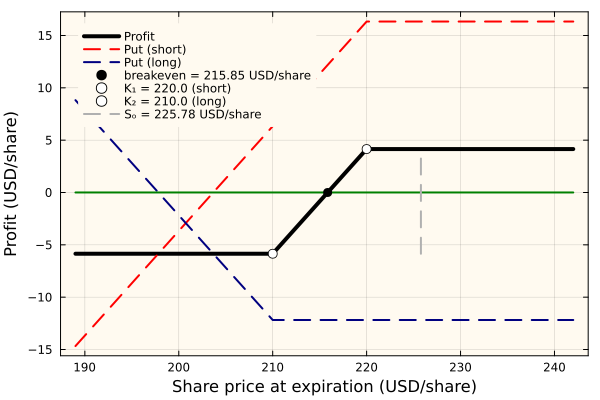

In [6]:
let

    # initialize -
    options_dataset =  optionschain;
    K₁ = 220.0 # short put strike price
    K₂ = 210.0 # long put strike price
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K₁ && y == "Put"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K₂ && y == "Put"), options_dataset)[1,:Mid];
     
    max_loss = K₂ - K₁ + (premium_1 - premium_2);
    max_profit = (premium_1 - premium_2);
    
    put_contract_model_short = build(MyAmericanPutContractModel, (
            K = K₁, premium = premium_1, sense = -1, copy = 1
    ));

    put_contract_model_long = build(MyAmericanPutContractModel, (
            K = K₂, premium = premium_2, sense = 1, copy = 1
    ));
    
    S = range(0.9*K₂,stop = 1.1*K₁, step=0.1) |> collect;
    number_of_steps = length(S);
    BEL = zeros(length(S))
    profit_array = profit([put_contract_model_short, put_contract_model_long], S);
    breakeven = K₁ + (premium_2 - premium_1)
    
    plot(profit_array[:,1], profit_array[:,4], lw=4, label="Profit", c=:black, 
        bg="floralwhite", 	background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    plot!(profit_array[:,1], profit_array[:,2], lw=2, label="Put (short)", ls=:dash, c=:red)
    plot!(profit_array[:,1], profit_array[:,3], lw=2, label="Put (long)", ls=:dash, c=:navyblue)
    
    plot!(S,BEL,lw=2, c=:green, label="")
    scatter!([breakeven], [0], c=:black, label="breakeven = $(round(breakeven,digits=2)) USD/share", ms=5)
    scatter!([K₁],[max_profit], ms=5, label = "K₁ = $(K₁) (short)", msc=:black, mc=:white)
    scatter!([K₂],[max_loss], ms=5, label = "K₂ = $(K₂) (long)", msc=:black, mc=:white)

    VLINE = zeros(number_of_steps, 2)
    VLINE[:,1] .= Sₒ*ones(number_of_steps)
    VLINE[:,2] .= range(minimum(profit_array[:,end]), stop = maximum(profit_array[:,end]), length = number_of_steps) |> collect;
    plot!(VLINE[:,1], VLINE[:,2], lw=2, c= :gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")
    
    xlabel!("Share price at expiration (USD/share)", fontsize=18)
    ylabel!("Profit (USD/share)", fontsize=18)
end

### Bearish call credit spread
A bearish call credit spread is an options strategy used when a trader expects a __decline__ in the price of the underlying asset. This trade structure is constructed by selling (short) a call with strike $K_{1}$ and buying (long) a call with strike $K_{2}$ with $K_{1}<K_{2}$. 

> __Bearish call credit spread__
> 
> Let's build a bearish call credit spread on AMD whose recorded share price is $S_{0} = 225.78$ USD/share. 
> This trade structure is constructed by selling (short) a call with strike $K_{1}$ and buying (long) a call with strike $K_{2}$. 
> 
> * Leg 1: The strike price for the short call leg is given by $K_{1} = 210$ USD/share.
> * Leg 2: The strike price for the long call leg is given by $K_{2} = 240$ USD/share.
> 
> This trade has a bearish outlook on the underlying asset. This trade will generate a net credit when opened. Depending on the share price at expiration, the trade can result in a defined profit or loss. The maximum profit occurs when the share price at expiration is below the lower strike price $K_{1}$. The maximum loss occurs when the share price at expiration is above the higher strike price $K_{2}$.

#### Profit and Breakeven Analysis
The profit function for the bear call credit spread is given by:
$$
\Pi_{\mathcal{C}} = (S_{T}-K_{2})^{+} - (S_{T}-K_{1})^{+} + (P_{1}-P_{2})
$$

where $h_{c}(S_{T};K) = (S_{T}-K)^{+}=\max(S_{T}-K,0)$ is the payoff function for a call contract at expiration. The first two terms are the net payout of the two legs of the spread, while the last term is the net credit received when the position opens. The maximum possible profit, loss, and breakeven conditions are given by:

* The maximum profit, the net credit $\left(P_{1} - P_{2}\right)$, occurs when $S_{T}\leq{K_{1}}$.
* The __minimum profit__ $\left(P_{1} - P_{2}\right) - (K_{2} - K_{1})$ occurs when $S_{T}\geq{K_{2}}$. This is a signed profit and is negative whenever the credit is smaller than the strike width; the __loss magnitude__ is $(K_{2}-K_{1}) - \left(P_{1} - P_{2}\right)$.
* The bear call spread will breakeven when $S_{T} = K_{1}+\left(P_{1} - P_{2}\right)$.

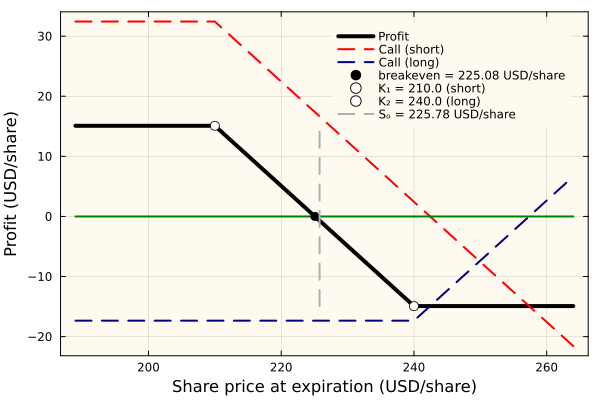

In [7]:
let

    # initialize -
    options_dataset =  optionschain;
    K₁ = 210.0 # short call strike price
    K₂ = 240.0 # long call strike price
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K₁ && y == "Call"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K₂ && y == "Call"), options_dataset)[1,:Mid];

    max_loss = (premium_1 - premium_2) - (K₂ - K₁)
    max_profit = (premium_1 - premium_2);
    
    call_contract_model_short = build(MyAmericanCallContractModel, (
            K = K₁, premium = premium_1, sense = -1, copy = 1
    ));

    call_contract_model_long = build(MyAmericanCallContractModel, (
            K = K₂, premium = premium_2, sense = 1, copy = 1
    ));
    
    S = range(0.9*K₁,stop = 1.1*K₂, step=0.1) |> collect;
    number_of_steps = length(S);
    BEL = zeros(length(S))
    profit_array = profit([call_contract_model_short, call_contract_model_long], S);
    breakeven = K₁ + (premium_1 - premium_2)
    
    plot(profit_array[:,1], profit_array[:,4], lw=4, label="Profit", c=:black, 
        bg="floralwhite", 	background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    plot!(profit_array[:,1], profit_array[:,2], lw=2, label="Call (short)", ls=:dash, c=:red)
    plot!(profit_array[:,1], profit_array[:,3], lw=2, label="Call (long)", ls=:dash, c=:navyblue)
    
    plot!(S,BEL,lw=2, c=:green, label="")
    scatter!([breakeven], [0], c=:black, label="breakeven = $(round(breakeven,digits=2)) USD/share", ms=5)
    scatter!([K₁],[max_profit], ms=5, label = "K₁ = $(K₁) (short)", msc=:black, mc=:white)
    scatter!([K₂],[max_loss], ms=5, label = "K₂ = $(K₂) (long)", msc=:black, mc=:white)

    VLINE = zeros(number_of_steps, 2)
    VLINE[:,1] .= Sₒ*ones(number_of_steps)
    VLINE[:,2] .= range(minimum(profit_array[:,end]), stop = maximum(profit_array[:,end]), length = number_of_steps) |> collect;
    plot!(VLINE[:,1], VLINE[:,2], lw=2, c= :gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")
    
    xlabel!("Share price at expiration (USD/share)", fontsize=18)
    ylabel!("Profit (USD/share)", fontsize=18)
end

___

## Task 2: Neutral: Straddles and Strangles
In this task, we will analyze two neutral option strategies: straddles and strangles. A straddle buys (or sells) a put and a call at the __same__ strike price; a strangle uses __different__ strike prices.

### Straddles
A [straddle](https://www.investopedia.com/terms/s/straddle.asp) is a _neutral strategy_ constructed by simultaneously buying (or selling) a put and a call option on the same underlying asset `XYZ`, with the _same expiration_, and the _same strike price_. 

> __Long (short) straddle__
> 
> Let's build a long (short) straddle on AMD whose recorded share price is $S_{0} = 225.78$ USD/share. For a long straddle, we purchase (are long) both the put and the call contracts in the straddle ($\theta = 1$). For a short straddle, we sell (are short) both the put and the call contracts in the straddle ($\theta = -1$). For a straddle, both legs have the same strike price $K$.
>
> Let's construct the profit diagram for a long (short) straddle with the parameters:
> * Leg 1: The strike price for the long (short) put leg is given by $K_{1}$ = 230 USD/share with DTE = 58 days
> * Leg 2: The strike price for the long (short) call leg is given by $K_{2}$ = 230 USD/share with DTE = 58 days
> 
> In this example, we demonstrate a **short straddle** ($\theta = -1$), showing the profit and loss when both legs are sold.

#### Profit and Breakeven Analysis
Let $K_{i}$ denote the strike price of leg $i$ (USD/share) and $P_{i}\geq{0}$ its premium (USD/share). Let index $i=1$ denote the put and $i=2$ the call; for a straddle $K_{1}=K_{2}\equiv{K}$. Write the total premium as $D = P_{1}+P_{2}$, the net debit paid (long) or credit received (short). The profit of the straddle at expiration is given by:

$$\Pi_{\mathcal{C}}(S_{T}) = \theta\cdot\left(\Pi_{1}^{(p)}+\Pi_{2}^{(c)}\right)$$

where $\theta_{1}=\theta_{2}\equiv\theta$ is the direction: $\theta=-1$ if both legs are sold (short), $\theta=+1$ if both are bought (long). Substituting the per-leg profit functions gives:

$$\Pi_{\mathcal{C}}(S_{T}) = \theta\cdot\Bigl[(K-S_{T})^{+}+(S_{T}-K)^{+}-D\Bigr] = \theta\cdot\Bigl[\,\lvert S_{T}-K\rvert - D\,\Bigr]$$

where the second equality uses the identity $(K-S_{T})^{+}+(S_{T}-K)^{+} = \lvert S_{T}-K\rvert$: whichever leg is out of the money contributes zero, and the other contributes the distance from the strike. The profit therefore has two linear branches meeting at $S_{T}=K$:

$$
\Pi_{\mathcal{C}}(S_{T}) = \begin{cases}
  \theta\cdot\Bigl[(S_{T}-K)-D\Bigr]  & S_{T}\geq{K} \\
  \theta\cdot\Bigl[(K-S_{T})-D\Bigr] & S_{T}<K
\end{cases}
$$

A straddle has _two_ breakeven prices, $S^{-}$ and $S^{+}$, one on each branch:
* Upper branch: $S^{+} = K + D$
* Lower branch: $S^{-} = K - D$

##### Bounds: only the upside is unbounded
The two branches are __not__ mirror images, because $S_{T}\geq{0}$ truncates the lower one. Reading the extremes off the branches:

| Position | At $S_{T}=K$ | As $S_{T}\to\infty$ | At $S_{T}=0$ |
|---|---|---|---|
| Long straddle ($\theta=+1$) | maximum loss $D$ | profit unbounded | profit $K-D$, __finite__ |
| Short straddle ($\theta=-1$) | maximum profit $D$ | loss unbounded | loss $K-D$, __finite__ |

> __The common phrasing is wrong.__ A long straddle is often described as having "unlimited profit if the price moves significantly in either direction," and a short straddle as having "unlimited loss in either direction." Neither is correct on the downside. The best a long straddle can do if the underlying collapses is $K-D$ per share, reached at $S_{T}=0$, because the put cannot pay more than its strike. The word _unlimited_ applies only to the call leg, and only as $S_{T}\to\infty$. On the AMD straddle below, $K = 230$ and $D \approx 42.88$ USD/share. The long side's profit if AMD went to zero would be $K-D \approx 187.12$ USD/share and no more, while its profit as $S_{T}$ rises has no bound at all. Note that $K-D$ appears twice in this example with two different meanings: as a __price__ it is the lower breakeven $S^{-}=187.12$ USD/share, and as a __profit__ it is the capped downside $187.12$ USD/share. The two are equal by algebra, not by coincidence, but they are not the same quantity.

Both directions come from the same profit function with only $\theta$ flipped, so let's compute both rather than assert one of them in prose. The table below evaluates the profit curve at the two prices the bounds table names, $S_{T}=0$ and $S_{T}=K$, for $\theta=+1$ and $\theta=-1$, and checks each value against its closed form:

In [8]:
let

    # initialize -
    options_dataset =  optionschain;
    K = 230.0; # strike price (USD/share)
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K && y == "Put"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K && y == "Call"), options_dataset)[1,:Mid];
    D = premium_1 + premium_2; # total premium: debit if long, credit if short (USD/share)

    # evaluate at the two prices named in the bounds table: the left boundary and the kink -
    S = [0.0, K];

    direction_array = String[];
    profit_at_kink_array = Float64[];
    profit_at_zero_array = Float64[];
    lower_breakeven_array = Float64[];
    upper_breakeven_array = Float64[];

    for θ ∈ [1, -1] # 1 = long straddle, -1 = short straddle

        put_contract_model = build(MyAmericanPutContractModel, (
                K = K, premium = premium_1, sense = θ, copy = 1
        ));

        call_contract_model = build(MyAmericanCallContractModel, (
                K = K, premium = premium_2, sense = θ, copy = 1
        ));

        profit_array = profit([put_contract_model, call_contract_model], S);
        profit_at_zero = profit_array[1,end]; # S_T = 0
        profit_at_kink = profit_array[2,end]; # S_T = K

        # the computed curve must agree with the closed forms in BOTH directions -
        @assert isapprox(profit_at_zero, θ*(K - D); atol = 1e-9) "straddle profit at S_T = 0 does not equal θ(K - D) for θ = $(θ)"
        @assert isapprox(profit_at_kink, -1*θ*D; atol = 1e-9) "straddle profit at the kink does not equal -θD for θ = $(θ)"
        @assert isfinite(profit_at_zero) "straddle profit at S_T = 0 is not finite for θ = $(θ)"

        push!(direction_array, θ == 1 ? "long (θ = +1)" : "short (θ = -1)");
        push!(profit_at_kink_array, round(profit_at_kink, digits=2));
        push!(profit_at_zero_array, round(profit_at_zero, digits=2));
        push!(lower_breakeven_array, round(K - D, digits=2));
        push!(upper_breakeven_array, round(K + D, digits=2));
    end

    DataFrame(direction = direction_array, profit_at_K = profit_at_kink_array,
        profit_at_zero = profit_at_zero_array, lower_breakeven = lower_breakeven_array,
        upper_breakeven = upper_breakeven_array)
end

Row,direction,profit_at_K,profit_at_zero,lower_breakeven,upper_breakeven
,String,Float64,Float64,Float64,Float64
1,long (θ = +1),-42.88,187.12,187.12,272.88
2,short (θ = -1),42.88,-187.12,187.12,272.88


The long row carries the numbers quoted above: a profit of $187.12$ USD/share at $S_{T}=0$ and nothing beyond it, against an upside with no bound at all. The short row is that row with every profit sign reversed. The two breakeven prices, however, are identical in both rows: direction flips the sign of the profit, not the prices at which the profit crosses zero. The figure below plots the __short__ side, $\theta=-1$.

So what do we see?

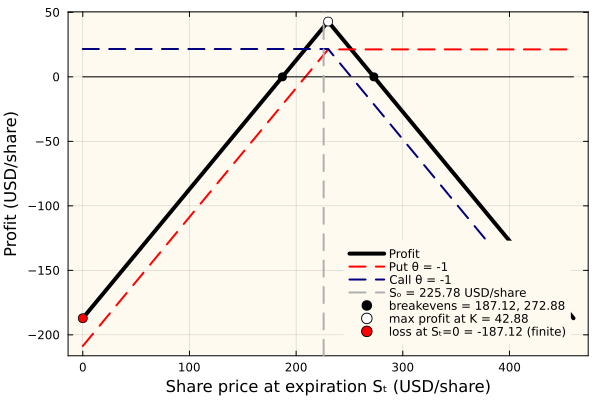

In [9]:
let
    
    # initialize -
    options_dataset =  optionschain;
    θ = -1; # 1 = long straddle, -1 = short straddle
    K = 230.0; # strike price (USD/share)
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K && y == "Put"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K && y == "Call"), options_dataset)[1,:Mid];
    D = premium_1 + premium_2; # total premium: debit if long, credit if short (USD/share)

    # profit at the kink S_T = K. For θ = -1 (short) this is the MAXIMUM PROFIT (+D);
    # for θ = +1 (long) it is the MAXIMUM LOSS (-D). It is not a loss in both cases,
    # so name it for what it is: the profit at the kink.
    profit_at_kink = -1*θ*D;

    # profit at the left boundary S_T = 0. FINITE for either direction: θ*(K - D).
    profit_at_zero = θ*(K - D);
    
    put_contract_model = build(MyAmericanPutContractModel, (
            K = K, premium = premium_1, sense = θ, copy = 1
    ));

    call_contract_model = build(MyAmericanCallContractModel, (
            K = K, premium = premium_2, sense = θ, copy = 1
    ));

    # sweep from the left boundary S_T = 0 to S_T = 2K, so the bounded downside is visible -
    S = range(0.0, stop = 2.0*K, step = 0.5) |> collect;
    number_of_steps = length(S);
    BEL = zeros(length(S))
    profit_array = profit([put_contract_model, call_contract_model], S);
    
    breakeven_array = zeros(2,2);
    breakeven_array[1,1] = K + D;
    breakeven_array[2,1] = K - D;

    # verify the analytical bounds against the computed curve -
    @assert isapprox(profit_array[1,end], profit_at_zero; atol = 1e-9) "straddle profit at S_T = 0 does not equal θ(K - D)"
    @assert isfinite(profit_array[1,end]) "straddle profit at S_T = 0 is not finite"
    
    plot(profit_array[:,1], profit_array[:,4], lw=4, label="Profit", c=:black, 
        bg="floralwhite", 	background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    plot!(profit_array[:,1], profit_array[:,2], lw=2, label="Put θ = $(θ)", ls=:dash, c=:red)
    plot!(profit_array[:,1], profit_array[:,3], lw=2, label="Call θ = $(θ)", ls=:dash, c=:navyblue)
    plot!(S,BEL,lw=1, c=:black, label="")
    
    vline!([Sₒ], lw=2, c=:gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")
    
    scatter!(breakeven_array[:,1], breakeven_array[:,2], c=:black, ms=5,
        label="breakevens = $(round(K-D,digits=2)), $(round(K+D,digits=2))")
    scatter!([K],[profit_at_kink], ms=5, mc=:white, msc=:black,
        label="max profit at K = $(round(profit_at_kink,digits=2))")
    scatter!([0.0],[profit_at_zero], ms=5, mc=:red, msc=:black,
        label="loss at Sₜ=0 = $(round(profit_at_zero,digits=2)) (finite)")
    
    xlabel!("Share price at expiration Sₜ (USD/share)", fontsize=18)
    ylabel!("Profit (USD/share)", fontsize=18)
end

### Strangles
A [strangle](https://www.investopedia.com/terms/s/strangle.asp) position is a _neutral strategy_ constructed by simultaneously buying or selling a put and a call option on the same underlying asset `XYZ`, with the _same expiration_ but with _different strike prices_. 

> __Long (short) Strangle:__
> 
> Let's build a long (short) strangle on AMD. For a long strangle, we purchase (are long) both the put and the call contracts in the strangle ($\theta = 1$). For a short strangle, we sell (are short) both ($\theta = -1$). The put strike $K_{1}$ is less than the call strike $K_{2}$. 
> 
>  Let's construct the profit diagram for a long (short) strangle with the parameters:
> * Leg 1: The strike price for the long (short) put leg is given by $K_{1}$ = 210 USD/share with DTE = 58 days
> * Leg 2: The strike price for the long (short) call leg is given by $K_{2}$ = 240 USD/share with DTE = 58 days
> 
> In this example, we demonstrate a **short strangle** ($\theta = -1$), showing the profit and loss when both legs are sold. 

#### Profit and Breakeven Analysis
Let $K_{i}$ denote the strike price of leg $i$ (USD/share) and $P_{i}\geq{0}$ its premium (USD/share). Let index $i=1$ denote the put and $i=2$ the call; for a strangle $K_{1}<K_{2}$. Write the total premium as $D = P_{1}+P_{2}$. The profit of the strangle at expiration is given by:

$$\Pi_{\mathcal{C}}(S_{T}) = \theta\cdot\left(\Pi_{1}^{(p)}+\Pi_{2}^{(c)}\right)$$

where $\theta_{1}=\theta_{2}\equiv\theta$ is the direction: $\theta=-1$ if both legs are sold (short), $\theta=+1$ if both are bought (long). Substituting the per-leg profit functions gives:

$$\Pi_{\mathcal{C}}(S_{T}) = \theta\cdot\Bigl[(K_{1}-S_{T})^{+}+(S_{T}-K_{2})^{+}-D\Bigr]$$

Unlike the straddle, the two kinked terms are never both active, and between the strikes __neither__ is. The profit therefore has three regimes:

$$
\Pi_{\mathcal{C}}(S_{T}) = \begin{cases}
  \theta\cdot\Bigl[(S_{T}-K_{2})-D\Bigr]  & S_{T}>K_{2} \\
  -\theta\cdot D & K_{1}\leq{S_{T}}\leq{K_{2}} \\
  \theta\cdot\Bigl[(K_{1}-S_{T})-D\Bigr] & S_{T}<{K_{1}}
\end{cases}
$$

The flat middle regime is the difference between a strangle and a straddle. For the __short__ side it trades a smaller maximum profit for a whole _interval_ over which that maximum is earned, rather than the straddle's single point; for the __long__ side the same flat region is a smaller maximum loss, spread over an interval instead of a point.

A strangle has two breakeven prices $S^{-}<K_{1}$ and $S^{+}>K_{2}$, one on each sloped branch:

$$S^{-} = K_{1} - D \qquad\text{and}\qquad S^{+} = K_{2} + D$$

##### Bounds: again, only the upside is unbounded
| Position | On $[K_{1},K_{2}]$ | As $S_{T}\to\infty$ | At $S_{T}=0$ |
|---|---|---|---|
| Long strangle ($\theta=+1$) | maximum loss $D$ | profit unbounded | profit $K_{1}-D$, __finite__ |
| Short strangle ($\theta=-1$) | maximum profit $D$ | loss unbounded | loss $K_{1}-D$, __finite__ |

> __The same correction as the straddle.__ A long strangle is often said to have "unlimited profit if the price moves significantly beyond either strike," and a short strangle "unlimited loss beyond either strike." Beyond the __upper__ strike, yes. Beyond the __lower__ strike, no: the put leg cannot pay more than $K_{1}$, so the downside branch terminates at $S_{T}=0$ with a profit of $K_{1}-D$ for the long side and a loss of the same size for the short side. On the AMD strangle below, $K_{1} = 210$ and $D \approx 29.53$ USD/share, so the long side's downside profit stops at $180.47$ USD/share while its upside has no bound.
>
> As with the straddle, the number $K_{1}-D = 180.47$ shows up twice with two meanings: as a __price__ it is the lower breakeven $S^{-}$, and as a __profit__ it is the capped downside. Equal by algebra, different quantities.

Again, let's compute both directions rather than assert one of them. The table below evaluates the profit curve at $S_{T}=0$ and at both strikes for $\theta=+1$ and $\theta=-1$, checks each value against its closed form, and checks that the profit really is flat between the strikes:

In [10]:
let

    # initialize -
    options_dataset =  optionschain;
    K₁ = 210.0; # put strike (USD/share)
    K₂ = 240.0; # call strike (USD/share)
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K₁ && y == "Put"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K₂ && y == "Call"), options_dataset)[1,:Mid];
    D = premium_1 + premium_2; # total premium: debit if long, credit if short (USD/share)

    # evaluate at the left boundary and at both ends of the flat middle regime -
    S = [0.0, K₁, K₂];

    direction_array = String[];
    profit_on_plateau_array = Float64[];
    profit_at_zero_array = Float64[];
    lower_breakeven_array = Float64[];
    upper_breakeven_array = Float64[];

    for θ ∈ [1, -1] # 1 = long strangle, -1 = short strangle

        put_contract_model = build(MyAmericanPutContractModel, (
                K = K₁, premium = premium_1, sense = θ, copy = 1
        ));

        call_contract_model = build(MyAmericanCallContractModel, (
                K = K₂, premium = premium_2, sense = θ, copy = 1
        ));

        profit_array = profit([put_contract_model, call_contract_model], S);
        profit_at_zero = profit_array[1,end];    # S_T = 0
        profit_on_plateau = profit_array[2,end]; # S_T = K₁

        # the computed curve must agree with the closed forms in BOTH directions -
        @assert isapprox(profit_at_zero, θ*(K₁ - D); atol = 1e-9) "strangle profit at S_T = 0 does not equal θ(K₁ - D) for θ = $(θ)"
        @assert isapprox(profit_on_plateau, -1*θ*D; atol = 1e-9) "strangle plateau profit does not equal -θD for θ = $(θ)"
        @assert isapprox(profit_array[3,end], profit_on_plateau; atol = 1e-9) "strangle profit is not flat on [K₁,K₂] for θ = $(θ)"
        @assert isfinite(profit_at_zero) "strangle profit at S_T = 0 is not finite for θ = $(θ)"

        push!(direction_array, θ == 1 ? "long (θ = +1)" : "short (θ = -1)");
        push!(profit_on_plateau_array, round(profit_on_plateau, digits=2));
        push!(profit_at_zero_array, round(profit_at_zero, digits=2));
        push!(lower_breakeven_array, round(K₁ - D, digits=2));
        push!(upper_breakeven_array, round(K₂ + D, digits=2));
    end

    DataFrame(direction = direction_array, profit_on_plateau = profit_on_plateau_array,
        profit_at_zero = profit_at_zero_array, lower_breakeven = lower_breakeven_array,
        upper_breakeven = upper_breakeven_array)
end

Row,direction,profit_on_plateau,profit_at_zero,lower_breakeven,upper_breakeven
,String,Float64,Float64,Float64,Float64
1,long (θ = +1),-29.53,180.47,180.47,269.53
2,short (θ = -1),29.53,-180.47,180.47,269.53


The long row carries the quoted numbers: a profit of $180.47$ USD/share at $S_{T}=0$, numerically equal to the lower breakeven __price__ and again the end of the downside. Comparing the two tables shows what the wider strike spacing changes: the plateau is $29.53$ USD/share in magnitude against the straddle's $42.88$ USD/share at its kink. The extreme is smaller in either direction, a smaller maximum profit short and a smaller maximum loss long, and it is reached over an interval rather than at a single point.

What does a long (short) strangle profit diagram look like?

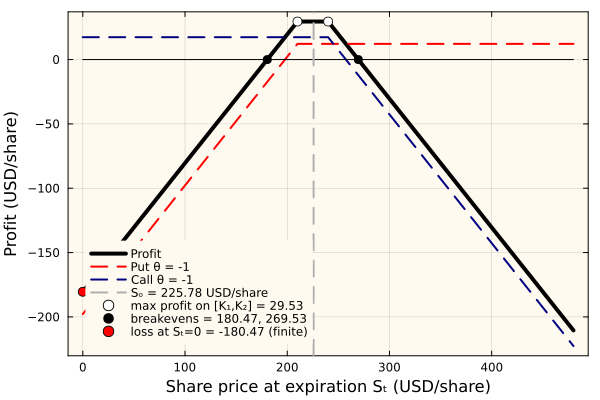

In [11]:
let

    # initialize -
    options_dataset =  optionschain;
    θ = -1; # 1 = long strangle, -1 = short strangle
    K₁ = 210.0; # put strike (USD/share)
    K₂ = 240.0; # call strike (USD/share)
    premium_1 = filter([:Strike,:Type] => (x,y) -> (x == K₁ && y == "Put"), options_dataset)[1,:Mid];
    premium_2 = filter([:Strike,:Type] => (x,y) -> (x == K₂ && y == "Call"), options_dataset)[1,:Mid];
    D = premium_1 + premium_2; # total premium: debit if long, credit if short (USD/share)

    # profit on the flat middle regime K₁ ≤ S_T ≤ K₂. For θ = -1 this is the MAXIMUM
    # PROFIT (+D); for θ = +1 it is the MAXIMUM LOSS (-D). Name it for what it is.
    profit_on_plateau = -1*θ*D;

    # profit at the left boundary S_T = 0. FINITE for either direction: θ*(K₁ - D).
    profit_at_zero = θ*(K₁ - D);
    
    put_contract_model = build(MyAmericanPutContractModel, (
            K = K₁, premium = premium_1, sense = θ, copy = 1
    ));

    call_contract_model = build(MyAmericanCallContractModel, (
            K = K₂, premium = premium_2, sense = θ, copy = 1
    ));
    
    # sweep from the left boundary S_T = 0 to S_T = 2K₂ -
    S = range(0.0, stop = 2.0*K₂, step = 0.5) |> collect;
    number_of_steps = length(S);
    BEL = zeros(length(S))
    profit_array = profit([put_contract_model, call_contract_model], S);
    
    breakeven_array = zeros(2,2);
    breakeven_array[1,1] = K₂ + D;
    breakeven_array[2,1] = K₁ - D;

    # verify the analytical bounds against the computed curve -
    @assert isapprox(profit_array[1,end], profit_at_zero; atol = 1e-9) "strangle profit at S_T = 0 does not equal θ(K₁ - D)"
    @assert isfinite(profit_array[1,end]) "strangle profit at S_T = 0 is not finite"
    
    plot(profit_array[:,1], profit_array[:,4], lw=4, label="Profit", c=:black, 
        bg="floralwhite", 	background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    plot!(profit_array[:,1], profit_array[:,2], lw=2, label="Put θ = $(θ)", ls=:dash, c=:red)
    plot!(profit_array[:,1], profit_array[:,3], lw=2, label="Call θ = $(θ)", ls=:dash, c=:navyblue)
    plot!(S,BEL,lw=1, c=:black, label="")
    
    vline!([Sₒ], lw=2, c=:gray69, ls=:dash, label="Sₒ = $(Sₒ) USD/share")
    
    scatter!([K₁, K₂],[profit_on_plateau, profit_on_plateau], ms=5, mc=:white, msc=:black,
        label="max profit on [K₁,K₂] = $(round(profit_on_plateau,digits=2))")
    scatter!(breakeven_array[:,1], breakeven_array[:,2], c=:black, ms=5,
        label="breakevens = $(round(K₁-D,digits=2)), $(round(K₂+D,digits=2))")
    scatter!([0.0],[profit_at_zero], ms=5, mc=:red, msc=:black,
        label="loss at Sₜ=0 = $(round(profit_at_zero,digits=2)) (finite)")
    
    xlabel!("Share price at expiration Sₜ (USD/share)", fontsize=18)
    ylabel!("Profit (USD/share)", fontsize=18)
end

___

## Summary
This example built composite option positions from signed legs and analyzed their payoff and profit at expiration. The neutral structures were swept over finite windows that start at $S_{T}=0$ and end at twice the call strike; the vertical spreads were plotted over a window around their strikes, where their two corners and both bounds lie.

> __Key Takeaways:__
> 
> * __Directional spreads have defined risk on both sides.__ A bullish put credit spread and a bearish call credit spread each cap the maximum profit at the net credit received and cap the maximum loss at the strike width less that credit. Both extremes are finite and known before the trade is placed, which is what "defined risk" means.
> * __Neutral strategies are unbounded on the upside only.__ A long straddle or strangle has a defined maximum loss (the net debit) and genuinely unbounded profit as $S_{T}\to\infty$; the short side reverses both. But the downside is __finite__ in every case, because $S_{T}\geq{0}$ caps the put leg at its strike. The common phrasing "unlimited in either direction" is wrong on the lower branch.
> * __Every structure is the same sum.__ Profit is $\Pi_{\mathcal{C}}(S_{T}) = \sum_{i}\theta_{i}n_{i}\left[h_{i}(S_{T})-P_{i}\right]$ per share in all four cases, which is what these figures plot; the deliverable $q_{i}$ enters only when converting a leg to account dollars. The strategy names are conventions for particular choices of leg type, strike, and direction; the mathematics does not change between them.

Reading a composite diagram means reading its corners, which sit at the strikes, and its vertical offset, which is the net debit or credit. L10b returns to these positions to compute the probability that one finishes profitable and to hedge the exposure that remains.
___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___